# Sentiment Analysis of IMDb Movie Reviews
### Comparing Simple RNN, LSTM, and GloVe-based LSTM models

| Item | Details |
|---|---|
| Module | 6CS012 - Artificial Intelligence and Machine Learning |
| Task | Part III - Natural Language Processing |
| Dataset | IMDb Movie Reviews, binary sentiment classification |
| Main objective | Predict whether a movie review is positive or negative |

## 0. Environment Setup
This section installs and imports the libraries used for preprocessing, visualisation, model training, and evaluation.

In [ ]:
# install everything we need -- only run this once per session
!pip install gensim --quiet
!pip install contractions --quiet
!pip install wordcloud --quiet
!python -c "import nltk; nltk.download('stopwords', quiet=True); nltk.download('wordnet', quiet=True); nltk.download('omw-1.4', quiet=True)"
print("setup done")


setup done


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, time, warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
from wordcloud import WordCloud
from collections import Counter

from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"GPU        : {bool(tf.config.list_physical_devices('GPU'))}")


TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : True


## 1. Loading the Dataset
The dataset is loaded from the extracted movie review files and separated into train, validation, and test splits.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("drive mounted")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
drive mounted


In [ ]:
import zipfile, os

zip_file_path  = '/content/movie-review.zip'
extraction_path = '/content/movie_review_dataset'
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as z:
    z.extractall(extraction_path)

print(f'extracted to: {extraction_path}')
print(os.listdir(extraction_path))


extracted to: /content/movie_review_dataset
['__MACOSX', 'movie-review']


In [ ]:
train_df = pd.read_csv('/content/movie_review_dataset/movie-review/train_movie_review.csv')
val_df   = pd.read_csv('/content/movie_review_dataset/movie-review/val_movie_review.csv')
test_df  = pd.read_csv('/content/movie_review_dataset/movie-review/test_movie_review.csv')

# tidy column names
for df in [train_df, val_df, test_df]:
    df.columns = [c.strip().lower() for c in df.columns]

# drop rows with no label
train_df.dropna(subset=['sentiment'], inplace=True)
val_df.dropna(subset=['sentiment'],   inplace=True)
test_df.dropna(subset=['sentiment'],  inplace=True)

# cast to int so keras doesn't complain
for df in [train_df, val_df, test_df]:
    df['sentiment'] = df['sentiment'].astype(int)
    df.reset_index(drop=True, inplace=True)

print(f"Train : {train_df.shape}")
print(f"Val   : {val_df.shape}")
print(f"Test  : {test_df.shape}")
train_df.head(3)


Train : (35000, 3)
Val   : (5000, 3)
Test  : (10000, 3)


,unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0


## 2. Data Understanding and Exploration
### 2.1 Dataset Overview
Before modelling, I checked the size of each split, the class balance, and the general shape of the review text.

In [ ]:
total = len(train_df) + len(val_df) + len(test_df)
print(f"Total reviews  : {total}")
print("Task           : Binary sentiment classification (positive / negative)")
print()

for df, name in [(train_df, 'Train'), (val_df, 'Val'), (test_df, 'Test')]:
    vc = df['sentiment'].value_counts()
    print(f"{name:6s}  Negative={vc.get(0, 0)}  Positive={vc.get(1, 0)}  Total={len(df)}")


Total reviews  : 50000
Task           : Binary sentiment classification (positive / negative)

Train   Negative=17584  Positive=17416  Total=35000
Val     Negative=2455  Positive=2545  Total=5000
Test    Negative=4961  Positive=5039  Total=10000


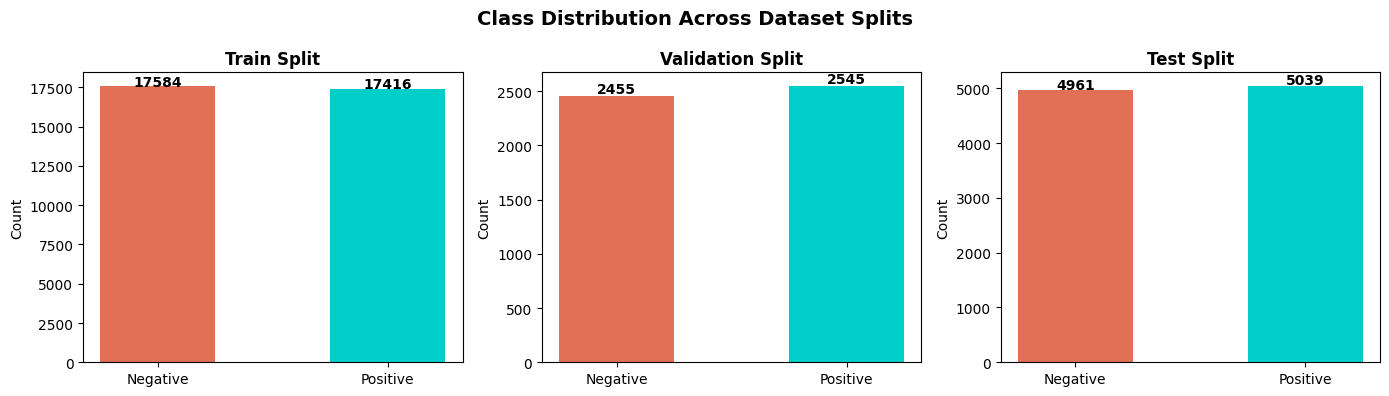

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#e17055', '#00cec9']

for ax, (df, title) in zip(axes, [(train_df, 'Train Split'),
                                   (val_df,   'Validation Split'),
                                   (test_df,  'Test Split')]):
    counts = df['sentiment'].value_counts().sort_index()
    bars = ax.bar(['Negative', 'Positive'], counts.values, color=colors, width=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 30, str(v),
                ha='center', fontweight='bold')

plt.suptitle('Class Distribution Across Dataset Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


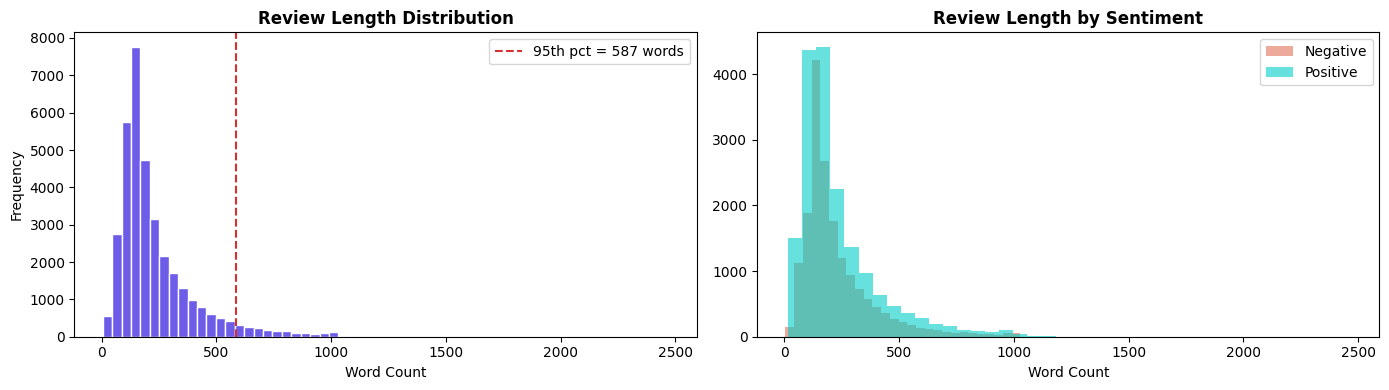

Mean   : 230.7 words
Median : 173.0 words
95th percentile: 587 words


In [ ]:
train_df['word_count'] = train_df['review'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df['word_count'], bins=60, color='#6c5ce7', edgecolor='white')
p95 = int(train_df['word_count'].quantile(0.95))
axes[0].axvline(p95, color='#d63031', linestyle='--', label=f'95th pct = {p95} words')
axes[0].set_title('Review Length Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

for sentiment, label, color in [(0, 'Negative', '#e17055'), (1, 'Positive', '#00cec9')]:
    axes[1].hist(train_df[train_df['sentiment'] == sentiment]['word_count'],
                 bins=40, alpha=0.6, label=label, color=color)
axes[1].set_title('Review Length by Sentiment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('review_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean   : {train_df['word_count'].mean():.1f} words")
print(f"Median : {train_df['word_count'].median():.1f} words")
print(f"95th percentile: {p95} words")


## 3. Text Preparation
### 3.1 Cleaning Pipeline
The same cleaning function is applied to train, validation, and test reviews so that all models receive comparable input text.

In [ ]:
STOP_WORDS = set(stopwords.words('english'))

NEGATIONS = {'not', 'no', 'nor', 'neither', 'never', 'none', "n't"}
STOP_WORDS = STOP_WORDS - NEGATIONS

lemmatizer = WordNetLemmatizer()

CONTRACTION_MAP = {
    "n't": " not", "'re": " are", "'s": " is", "'d": " would",
    "'ll": " will", "'ve": " have", "'m": " am"
}

def expand_contractions(text):
    for k, v in CONTRACTION_MAP.items():
        text = text.replace(k, v)
    return text

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)       # strip HTML tags (common in IMDB)
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS]
    return ' '.join(tokens)

print("Cleaning text...")
t0 = time.time()
train_df['clean'] = train_df['review'].astype(str).apply(clean_text)
val_df['clean']   = val_df['review'].astype(str).apply(clean_text)
test_df['clean']  = test_df['review'].astype(str).apply(clean_text)
print(f"Done in {time.time() - t0:.1f}s")

print("\nBefore:")
print(train_df['review'].iloc[0][:300])
print("\nAfter:")
print(train_df['clean'].iloc[0][:300])


Cleaning text...
Done in 35.5s

Before:
Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' - utter, utter cr**. I like ABBA, I like the songs, I have the old LPs. But this film is just terribl

After:
avoided seeing movie cinema buying dvd wife xmas watch not expect much usually mean get bargained amamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical race along song hurriedly following one another no characterisation dance number heavily choreographed


### 3.2 Frequent Words and Word Clouds
These visualisations give a quick sense of the most common cleaned tokens in positive and negative reviews.

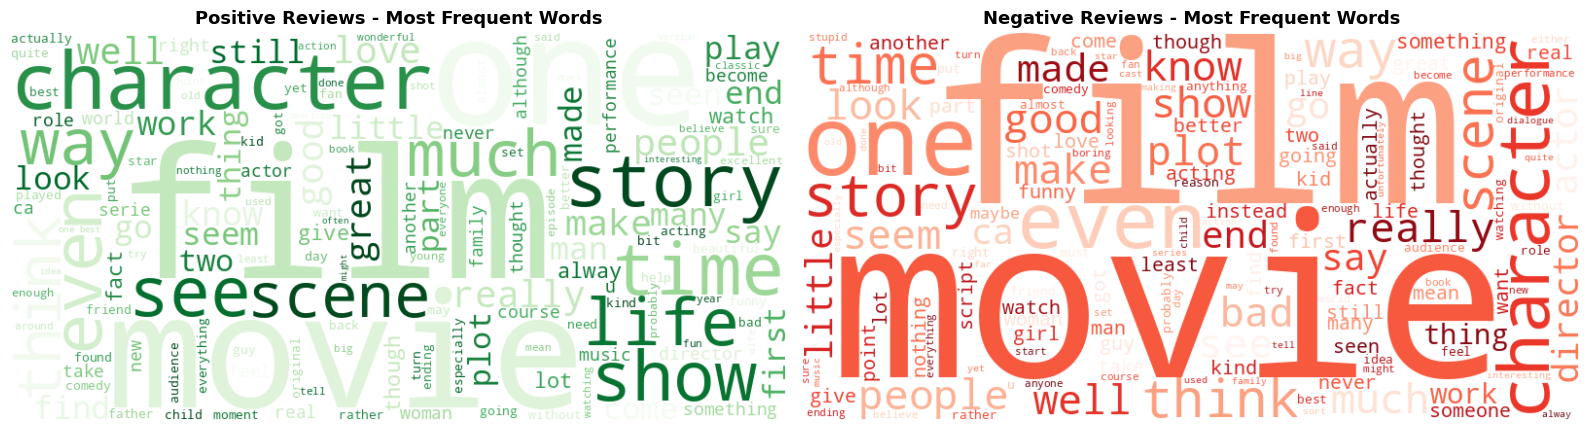

In [ ]:
pos_text = ' '.join(train_df[train_df['sentiment'] == 1]['clean'])
neg_text = ' '.join(train_df[train_df['sentiment'] == 0]['clean'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=150).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews - Most Frequent Words', fontsize=13, fontweight='bold')
axes[0].axis('off')

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=150).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews - Most Frequent Words', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()


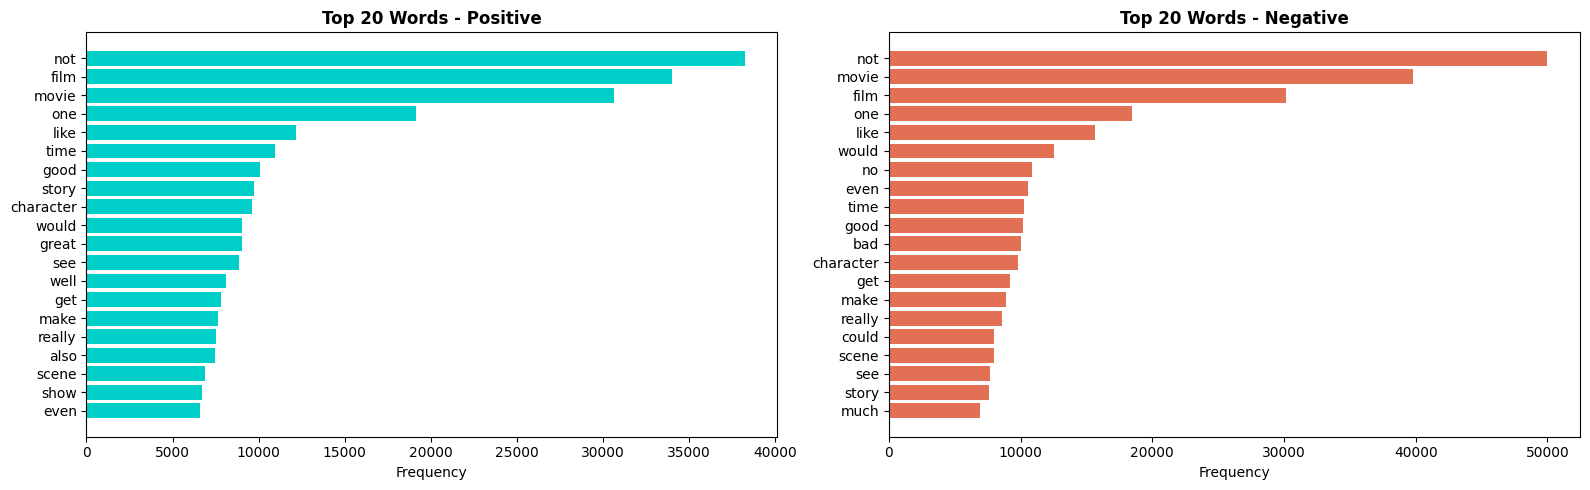

In [ ]:
def top_words(text, n=20):
    words, counts = zip(*Counter(text.split()).most_common(n))
    return list(words), list(counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, text, title, color in [
        (axes[0], pos_text, 'Top 20 Words - Positive', '#00cec9'),
        (axes[1], neg_text, 'Top 20 Words - Negative', '#e17055')]:
    words, counts = top_words(text)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Tokenisation and Padding
A Keras tokenizer is fitted on the training reviews only. The encoded sequences are then padded to fixed lengths for each model type.

In [ ]:
VOCAB_SIZE    = 10000
OOV_TOKEN     = '<OOV>'
MAX_LEN_RNN   = 100
MAX_LEN_LSTM  = 150
MAX_LEN_GLOVE = 150

# fit tokenizer on training data only
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_df['clean'])
word_index = tokenizer.word_index
print(f"Full vocab size : {len(word_index)}")
print(f"Keeping top     : {VOCAB_SIZE} words")

def encode(texts, maxlen):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=maxlen, padding='post', truncating='post')

X_train_r = encode(train_df['clean'], MAX_LEN_RNN)
X_val_r   = encode(val_df['clean'],   MAX_LEN_RNN)
X_test_r  = encode(test_df['clean'],  MAX_LEN_RNN)

X_train_s = encode(train_df['clean'], MAX_LEN_LSTM)
X_val_s   = encode(val_df['clean'],   MAX_LEN_LSTM)
X_test_s  = encode(test_df['clean'],  MAX_LEN_LSTM)

X_train_g = encode(train_df['clean'], MAX_LEN_GLOVE)
X_val_g   = encode(val_df['clean'],   MAX_LEN_GLOVE)
X_test_g  = encode(test_df['clean'],  MAX_LEN_GLOVE)

y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

print(f"\nModel 1 (RNN)   X_train : {X_train_r.shape}")
print(f"Model 2 (LSTM)  X_train : {X_train_s.shape}")
print(f"Model 3 (GloVe) X_train : {X_train_g.shape}")


Full vocab size : 119959
Keeping top     : 10000 words

Model 1 (RNN)   X_train : (35000, 100)
Model 2 (LSTM)  X_train : (35000, 150)
Model 3 (GloVe) X_train : (35000, 150)


## 4. Model Building and Training
### 4.1 Shared Training Settings
The three models use the same batch size and callback strategy, while learning rates are adjusted for each architecture.

In [ ]:
from tensorflow.keras.optimizers import Adam

EMBED_DIM  = 64
UNITS      = 64
BATCH_SIZE = 256
EPOCHS     = 15

def make_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=3,
                      restore_best_weights=True, verbose=1),
        # halve lr if stuck for 2 epochs
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-5, verbose=1)
    ]

histories   = {}
models      = {}
train_times = {}


### 4.2 Model 1: Simple RNN with Trainable Embedding
This baseline checks how well a basic recurrent layer can handle the review sequence after tokenisation.

In [ ]:
rnn_model = Sequential(name='Simple_RNN')
rnn_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                         input_length=MAX_LEN_RNN))
rnn_model.add(SimpleRNN(UNITS, activation='tanh', recurrent_dropout=0.2))
rnn_model.add(Dropout(0.4))
rnn_model.add(Dense(32, activation='relu'))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(loss='binary_crossentropy',
                  optimizer=Adam(learning_rate=1e-3),
                  metrics=['accuracy'])
rnn_model.build(input_shape=(None, MAX_LEN_RNN))
rnn_model.summary()


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,369 (2.48 MB)

 Trainable params: 650,369 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training Model 1 - Simple RNN")
t0 = time.time()
hist_rnn = rnn_model.fit(
    X_train_r, y_train,
    validation_data=(X_val_r, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1
)
train_times['RNN'] = time.time() - t0
histories['RNN']   = hist_rnn
models['RNN']      = rnn_model
print(f"\nTraining time: {train_times['RNN']:.1f}s")


Training Model 1 - Simple RNN
Epoch 1/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.5022 - loss: 0.7031 - val_accuracy: 0.4872 - val_loss: 0.6937 - learning_rate: 0.0010
Epoch 2/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4990 - loss: 0.6986 - val_accuracy: 0.4890 - val_loss: 0.6944 - learning_rate: 0.0010
Epoch 3/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5012 - loss: 0.6972
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5020 - loss: 0.6968 - val_accuracy: 0.4942 - val_loss: 0.6946 - learning_rate: 0.0010
Epoch 4/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5003 - loss: 0.6965 - val_accuracy: 0.4966 - val_loss: 0.6931 - learning_rate: 5.0000e-04
Epoch 5/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5035 - loss: 0.6961 - val_accuracy: 0.5020 - val_loss: 0.6934 - learning_rate: 5.0000e-04
Epoch 6/15
135/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1

### 4.3 Model 2: LSTM with Trainable Embedding
This model replaces the Simple RNN layer with an LSTM layer, allowing the network to keep or forget information through gates.

In [ ]:
lstm_model = Sequential(name='LSTM_Trainable_Embed')
lstm_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                          input_length=MAX_LEN_LSTM))
lstm_model.add(LSTM(UNITS, recurrent_dropout=0.2))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(loss='binary_crossentropy',
                   optimizer=Adam(learning_rate=3e-4),
                   metrics=['accuracy'])
lstm_model.build(input_shape=(None, MAX_LEN_LSTM))
lstm_model.summary()


Model: "LSTM_Trainable_Embed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,137 (2.58 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training Model 2 - LSTM (trainable embedding)")
t0 = time.time()
hist_lstm = lstm_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1
)
train_times['LSTM'] = time.time() - t0
histories['LSTM']   = hist_lstm
models['LSTM']      = lstm_model
print(f"\nTraining time: {train_times['LSTM']:.1f}s")


Training Model 2 - LSTM (trainable embedding)
Epoch 1/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 78s 520ms/step - accuracy: 0.5088 - loss: 0.6931 - val_accuracy: 0.5118 - val_loss: 0.6926 - learning_rate: 3.0000e-04
Epoch 2/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 72s 523ms/step - accuracy: 0.5399 - loss: 0.6873 - val_accuracy: 0.7514 - val_loss: 0.5277 - learning_rate: 3.0000e-04
Epoch 3/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 71s 517ms/step - accuracy: 0.7518 - loss: 0.5542 - val_accuracy: 0.8104 - val_loss: 0.4841 - learning_rate: 3.0000e-04
Epoch 4/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 70s 513ms/step - accuracy: 0.7933 - loss: 0.5109 - val_accuracy: 0.8222 - val_loss: 0.4660 - learning_rate: 3.0000e-04
Epoch 5/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 70s 510ms/step - accuracy: 0.7253 - loss: 0.5605 - val_accuracy: 0.7220 - val_loss: 0.5614 - learning_rate: 3.0000e-04
Epoch 6/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.6933 - loss: 0.5776
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246

### 4.4 Model 3: LSTM with Fine-tuned GloVe Embeddings
This model starts from pretrained 100-dimensional GloVe vectors and then fine-tunes them on the IMDb training data.

In [ ]:
import gensim.downloader as api

print("Downloading GloVe embeddings (glove-wiki-gigaword-100)...")
embedding_model = api.load('glove-wiki-gigaword-100')
GLOVE_DIM = 100
print("GloVe loaded.")


[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded.


In [ ]:
embedding_dim    = 100
vocab_size       = VOCAB_SIZE
embedding_matrix = np.zeros((vocab_size, embedding_dim))
hits, misses = 0, 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        hits += 1
    else:
        misses += 1

print(f"Words found in GloVe : {hits}")
print(f"Words not found      : {misses}")
print(f"Coverage             : {hits / (hits + misses) * 100:.1f}%")


Words found in GloVe : 9913
Words not found      : 86
Coverage             : 99.1%


In [ ]:
lstm_w2v = Sequential(name='LSTM_GloVe100_Finetuned')
lstm_w2v.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=MAX_LEN_GLOVE,
    trainable=True
))
lstm_w2v.add(LSTM(UNITS, recurrent_dropout=0.2))
lstm_w2v.add(Dropout(0.3))
lstm_w2v.add(Dense(32, activation='relu'))
lstm_w2v.add(Dense(1, activation='sigmoid'))

lstm_w2v.compile(loss='binary_crossentropy',
                 optimizer=Adam(learning_rate=1e-4),
                 metrics=['accuracy'])
lstm_w2v.build(input_shape=(None, MAX_LEN_GLOVE))
lstm_w2v.summary()


Model: "LSTM_GloVe100_Finetuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 150, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,353 (3.98 MB)

 Trainable params: 1,044,353 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training Model 3 - LSTM + GloVe-100")
t0 = time.time()
hist_w2v = lstm_w2v.fit(
    X_train_g, y_train,
    validation_data=(X_val_g, y_val),
    epochs=25,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1
)
train_times['LSTM_GloVe'] = time.time() - t0
histories['LSTM_GloVe']   = hist_w2v
models['LSTM_GloVe']      = lstm_w2v
print(f"\nTraining time: {train_times['LSTM_GloVe']:.1f}s")


Training Model 3 - LSTM + GloVe-100
Epoch 1/25
137/137 ━━━━━━━━━━━━━━━━━━━━ 73s 515ms/step - accuracy: 0.5109 - loss: 0.6926 - val_accuracy: 0.5192 - val_loss: 0.6885 - learning_rate: 1.0000e-04
Epoch 2/25
137/137 ━━━━━━━━━━━━━━━━━━━━ 83s 526ms/step - accuracy: 0.5301 - loss: 0.6868 - val_accuracy: 0.5394 - val_loss: 0.6764 - learning_rate: 1.0000e-04
Epoch 3/25
137/137 ━━━━━━━━━━━━━━━━━━━━ 76s 554ms/step - accuracy: 0.6449 - loss: 0.6409 - val_accuracy: 0.7446 - val_loss: 0.5555 - learning_rate: 1.0000e-04
Epoch 4/25
137/137 ━━━━━━━━━━━━━━━━━━━━ 74s 540ms/step - accuracy: 0.6928 - loss: 0.6035 - val_accuracy: 0.7584 - val_loss: 0.5419 - learning_rate: 1.0000e-04
Epoch 5/25
137/137 ━━━━━━━━━━━━━━━━━━━━ 74s 537ms/step - accuracy: 0.7360 - loss: 0.5714 - val_accuracy: 0.7628 - val_loss: 0.5358 - learning_rate: 1.0000e-04
Epoch 6/25
137/137 ━━━━━━━━━━━━━━━━━━━━ 70s 514ms/step - accuracy: 0.7323 - loss: 0.5762 - val_accuracy: 0.7718 - val_loss: 0.5266 - learning_rate: 1.0000e-04
Epoch 7/25

## 5. Training Curves
The plots below compare training and validation loss/accuracy for each model across the epochs actually completed before early stopping.

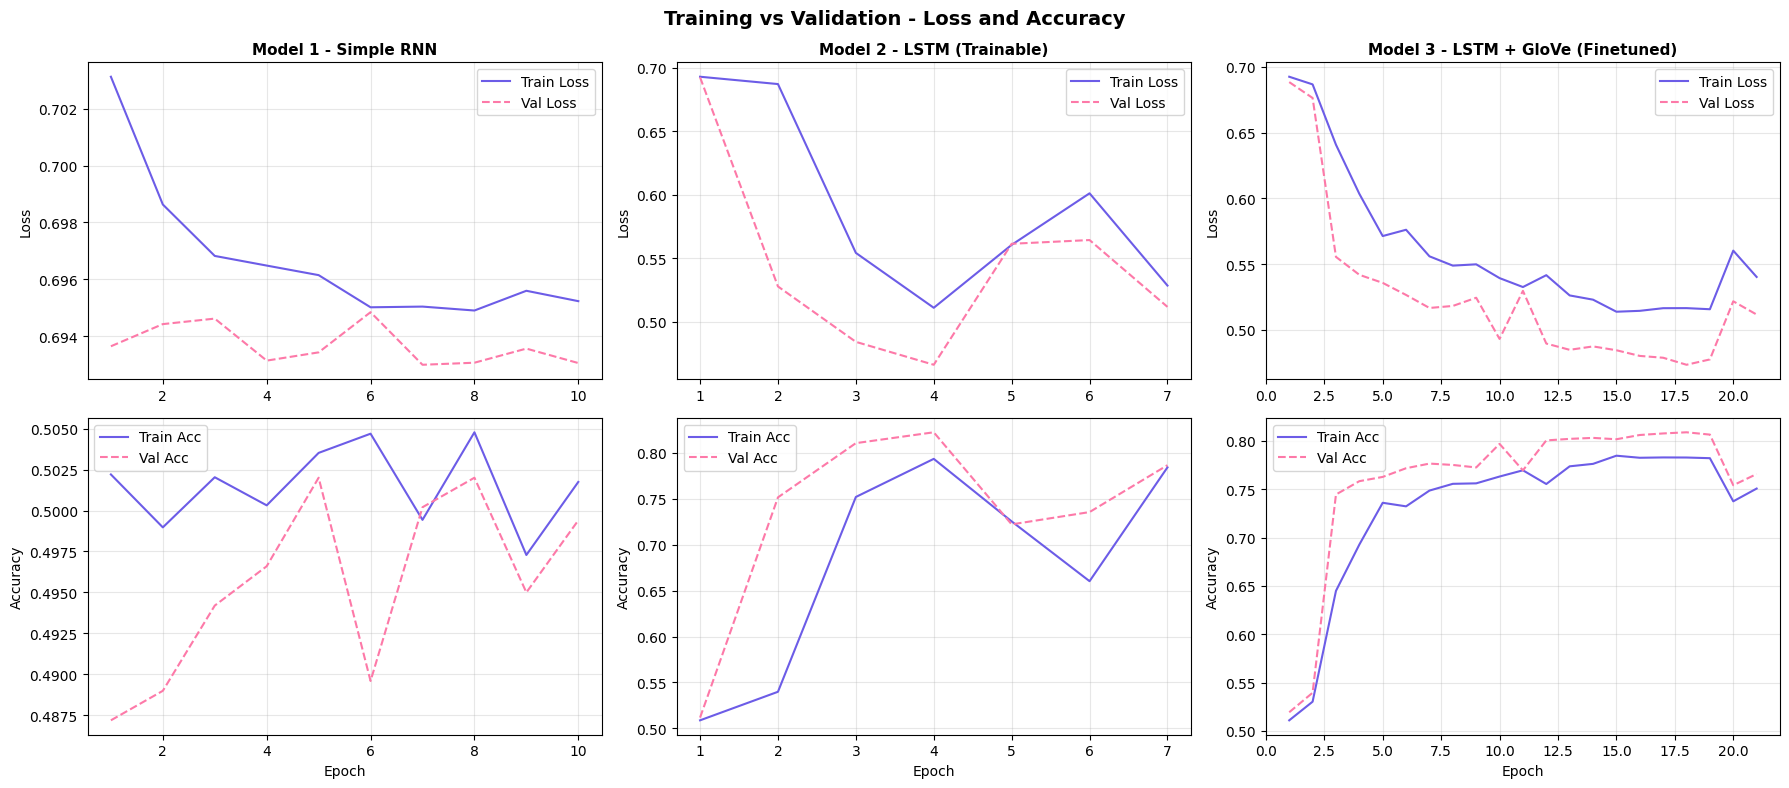

In [ ]:
def plot_history(hist, title, ax_loss, ax_acc):
    ep = range(1, len(hist.history['loss']) + 1)
    ax_loss.plot(ep, hist.history['loss'],     label='Train Loss', color='#6c5ce7')
    ax_loss.plot(ep, hist.history['val_loss'], label='Val Loss',   color='#fd79a8', linestyle='--')
    ax_loss.set_title(title, fontsize=11, fontweight='bold')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    ax_acc.plot(ep, hist.history['accuracy'],     label='Train Acc', color='#6c5ce7')
    ax_acc.plot(ep, hist.history['val_accuracy'], label='Val Acc',   color='#fd79a8', linestyle='--')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
plot_history(hist_rnn,  'Model 1 - Simple RNN',              axes[0][0], axes[1][0])
plot_history(hist_lstm, 'Model 2 - LSTM (Trainable)',        axes[0][1], axes[1][1])
plot_history(hist_w2v,  'Model 3 - LSTM + GloVe (Finetuned)', axes[0][2], axes[1][2])

plt.suptitle('Training vs Validation - Loss and Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Test Evaluation
### 6.1 Accuracy, Precision, Recall, and F1
Each trained model is evaluated on the same 10,000-review test set using a 0.5 decision threshold.

In [ ]:
def evaluate_model(model, X, y_true, name):
    y_prob = model.predict(X, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    print()
    print(f"  {name}")
    print(f"  Test Accuracy : {acc:.4f}")
    print()
    print(classification_report(y_true, y_pred,
                                target_names=['Negative', 'Positive']))
    return y_pred, acc

preds = {}
accs  = {}

preds['RNN'],        accs['RNN']        = evaluate_model(rnn_model,  X_test_r, y_test, 'Model 1 - Simple RNN')
preds['LSTM'],       accs['LSTM']       = evaluate_model(lstm_model, X_test_s, y_test, 'Model 2 - LSTM (Trainable)')
preds['LSTM_GloVe'], accs['LSTM_GloVe'] = evaluate_model(lstm_w2v,  X_test_g, y_test, 'Model 3 - LSTM + GloVe (Finetuned)')


### 6.2 Confusion Matrices
The confusion matrices show where each model makes false positive and false negative errors.

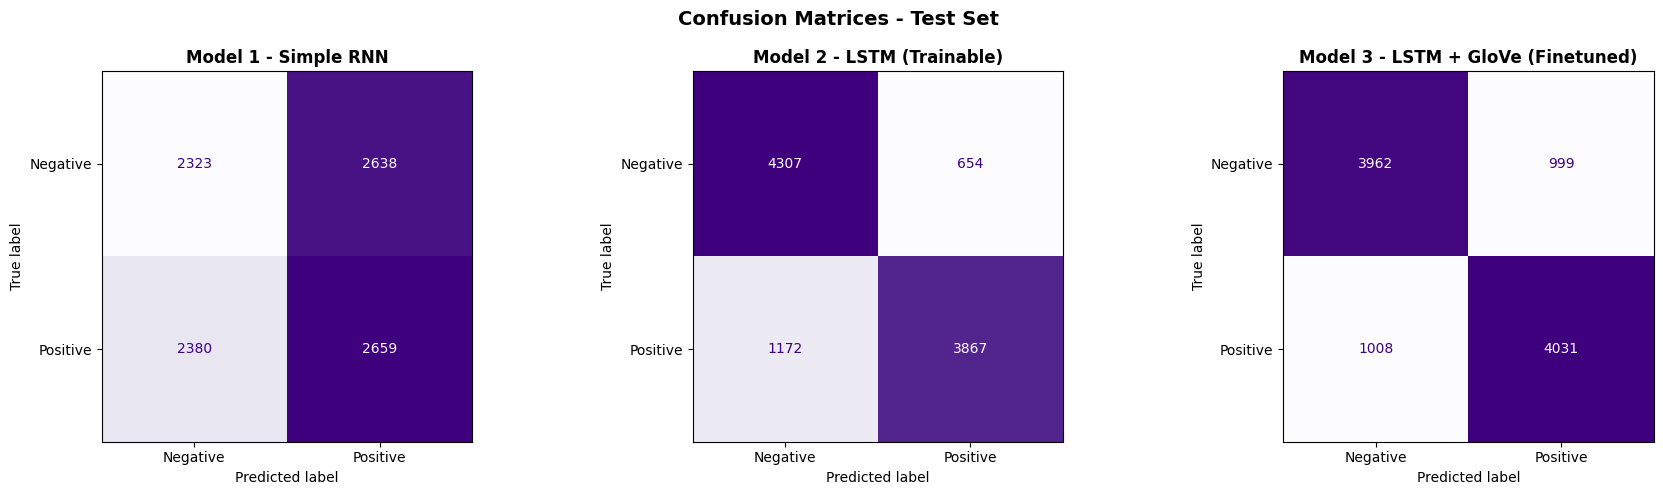

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_labels = ['Model 1 - Simple RNN',
                'Model 2 - LSTM (Trainable)',
                'Model 3 - LSTM + GloVe (Finetuned)']

for ax, key, title in zip(axes, ['RNN', 'LSTM', 'LSTM_GloVe'], model_labels):
    cm = confusion_matrix(y_test, preds[key])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, colorbar=False, cmap='Purples')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.3 Summary Comparison
The table and bar charts below compare final test metrics and total training time.

                   Model Accuracy Precision Recall F1-Score Train Time
              Simple RNN   0.4982    0.5020 0.5277   0.5145      26.1s
        LSTM (Trainable)   0.8174    0.8553 0.7674   0.8090     524.7s
LSTM + GloVe (Finetuned)   0.7993    0.8014 0.8000   0.8007    1570.9s


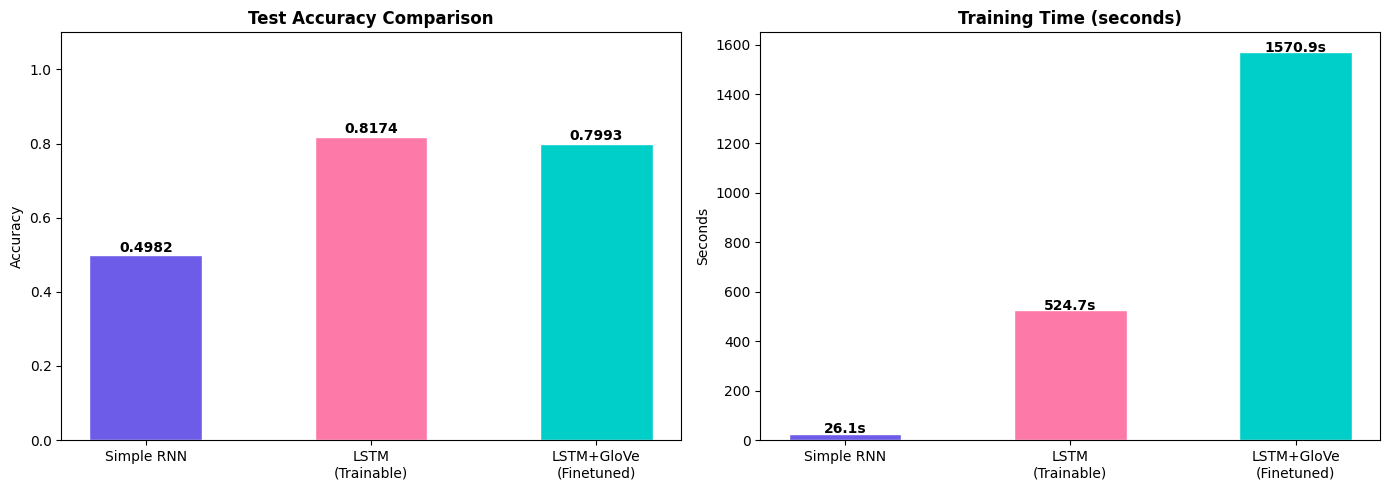

In [ ]:
rows = []
for key, label in [('RNN', 'Simple RNN'),
                   ('LSTM', 'LSTM (Trainable)'),
                   ('LSTM_GloVe', 'LSTM + GloVe (Finetuned)')]:
    yp = preds[key]
    rows.append({
        'Model'     : label,
        'Accuracy'  : f"{accs[key]:.4f}",
        'Precision' : f"{precision_score(y_test, yp):.4f}",
        'Recall'    : f"{recall_score(y_test, yp):.4f}",
        'F1-Score'  : f"{f1_score(y_test, yp):.4f}",
        'Train Time': f"{train_times[key]:.1f}s"
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

labels    = ['Simple RNN', 'LSTM\n(Trainable)', 'LSTM+GloVe\n(Finetuned)']
acc_vals  = [accs['RNN'], accs['LSTM'], accs['LSTM_GloVe']]
time_vals = [train_times['RNN'], train_times['LSTM'], train_times['LSTM_GloVe']]
colors    = ['#6c5ce7', '#fd79a8', '#00cec9']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(labels, acc_vals, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Accuracy')
for b, v in zip(bars, acc_vals):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.4f}',
                 ha='center', fontweight='bold')

bars2 = axes[1].bar(labels, time_vals, color=colors, width=0.5, edgecolor='white')
axes[1].set_title('Training Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Seconds')
for b, v in zip(bars2, time_vals):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.1f}s',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.4 Results Interpretation

> **Quick reading of the results:** the trainable LSTM is the best model in this run. It reaches the highest test accuracy and the strongest macro-level balance, while the GloVe LSTM is slightly more even between the two classes but less accurate overall.

| Model | Test accuracy | Main observation |
|---|---:|---|
| Simple RNN | 0.4982 | Stayed close to chance level and did not learn a useful sentiment boundary. |
| LSTM (trainable embedding) | 0.8174 | Best overall model, with strong positive precision and the highest number of correct predictions. |
| LSTM + GloVe (fine-tuned) | 0.7993 | Slightly lower accuracy than the trainable LSTM, but precision and recall are more evenly balanced. |

**Model 1: Simple RNN**

The Simple RNN achieved 49.82% accuracy, which is almost the same as random guessing on this balanced dataset. The confusion matrix shows 2,323 true negatives, 2,659 true positives, 2,638 false positives, and 2,380 false negatives. This means the model did not simply predict one class all the time; instead, it produced predictions across both labels but failed to separate positive and negative review patterns in a meaningful way. Its positive-class F1 score is 0.5145, while the macro F1 is about 0.4976.

**Model 2: LSTM with trainable embedding**

The LSTM with trainable embeddings performed best, reaching 81.74% test accuracy. It correctly classified 8,174 out of 10,000 reviews. Its positive precision is high at 0.8553, so when it predicts a review as positive, it is usually correct. However, positive recall is lower at 0.7674, meaning it still misses some genuinely positive reviews. From the confusion matrix, the model makes 654 false positive errors and 1,172 false negative errors. This shows a slightly conservative behaviour toward predicting the positive class.

**Model 3: LSTM with fine-tuned GloVe embeddings**

The GloVe-based LSTM reached 79.93% test accuracy, which is below the trainable LSTM but still much stronger than the Simple RNN. Its positive precision and recall are almost equal at 0.8014 and 0.8000, and its macro F1 is about 0.7993. The confusion matrix also looks balanced, with 999 false positives and 1,008 false negatives. This suggests that pretrained embeddings helped produce a steadier class balance, but in this run they did not improve the final accuracy beyond the task-specific trainable embedding.

**Overall conclusion**

The biggest improvement comes from replacing the Simple RNN with an LSTM. The LSTM gating mechanism is better suited to longer reviews because it can retain useful context over more time steps. Pretrained GloVe embeddings were useful, but not automatically better than embeddings trained directly on IMDb reviews. For this notebook output, the correct best model is **Model 2: LSTM with trainable embedding**.

## 7. Error Analysis
This section focuses on the current best model, the trainable LSTM, and explains the kinds of mistakes it is most likely to make.

In [ ]:
best_key   = max(accs, key=accs.get)
best_preds = preds[best_key]
print(f"Best model: {best_key}  |  Accuracy: {accs[best_key]:.4f}")
print()

mask   = best_preds != y_test
errors = test_df[mask].copy().reset_index(drop=True)
errors['predicted']  = best_preds[mask]
errors['true_label'] = y_test[mask]

print(f"Misclassified: {len(errors)} / {len(y_test)}  ({len(errors)/len(y_test)*100:.1f}%)")
print()

label_map = {0: 'Negative', 1: 'Positive'}
for i, row in errors.head(3).iterrows():
    print(f"--- Example {i+1} ---")
    print(f"  True label : {label_map[row['true_label']]}")
    print(f"  Predicted  : {label_map[row['predicted']]}")
    print(f"  Review     : {str(row['review'])[:300]}...")
    print()


### 7.1 Misclassified Examples and Failure Patterns

The best model is the **LSTM with trainable embedding**, not the GloVe model. It makes 1,826 mistakes on the 10,000-review test set, giving an error rate of 18.26%. The confusion matrix shows that false negatives are the larger problem: 1,172 positive reviews are predicted as negative, compared with 654 negative reviews predicted as positive.

#### Pattern 1: Positive reviews that begin with criticism

Some positive IMDb reviews start by mentioning a weakness, a confusing opening, or a negative expectation before later explaining why the movie worked overall. Because the sequences are capped at 150 tokens, the model may see the critical opening but miss the final positive judgement. This is one likely reason for the larger false-negative count.

#### Pattern 2: Mixed language inside one review

Movie reviews often combine praise and criticism in the same paragraph. A reviewer might praise the acting while criticising the pacing, or recommend the film while still using words such as "slow", "not", or "confusing". The LSTM captures more context than the Simple RNN, but it can still be pulled toward the negative class when several negative-sounding tokens appear early.

#### Pattern 3: Plot-heavy reviews with weak opinion words

Some reviews spend many words describing the story rather than directly stating whether the film is good or bad. After stopword removal and lemmatisation, these reviews can become mostly neutral plot vocabulary. In those cases the model has less direct sentiment evidence, so small wording cues can shift the prediction.

### 7.2 What the Errors Suggest

The model is learning useful sentiment patterns, but it is still limited by sequence length, word-level representation, and the absence of bidirectional context. The false-negative pattern suggests that the model sometimes gives too much weight to early negative wording and not enough weight to later positive conclusions.

### 7.3 Possible Improvements

- **Increase max_len:** using 250 or 300 tokens would allow more of each review to remain visible to the model, especially the conclusion.
- **Try a Bidirectional LSTM:** reading the sequence in both directions could help the model use later sentiment cues more effectively.
- **Tune the classification threshold:** since the best model has more false negatives than false positives, a slightly lower threshold may recover some positive reviews, although it may reduce precision.
- **Use attention or a Transformer model:** attention would help the model focus on the most sentiment-heavy words rather than compressing the whole review into one final recurrent state.
- **Expand the vocabulary:** increasing the vocabulary beyond 10,000 words may preserve more film-specific terms and reduce out-of-vocabulary loss.

## 8. Real-time Prediction Demo
The final cell creates a small interactive input box where a user can type a movie review and receive a sentiment prediction from the best saved model.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

title = widgets.HTML("<h3>IMDB Sentiment Analyser</h3><p>Best model: <b>" + best_key + "</b></p>")
text_input = widgets.Textarea(
    placeholder="Type a movie review here...",
    layout=widgets.Layout(width='600px', height='120px')
)
button = widgets.Button(description="Predict", button_style='primary')
output = widgets.Output()

def on_click(b):
    output.clear_output()
    with output:
        review = text_input.value
        if not review.strip():
            print("Please enter a review.")
            return

        cleaned = clean_text(review)

        if best_key == 'RNN':
            padded = pad_sequences(tokenizer.texts_to_sequences([cleaned]),
                                   maxlen=MAX_LEN_RNN, padding='post', truncating='post')
            model_to_use = rnn_model
        else:
            padded = pad_sequences(tokenizer.texts_to_sequences([cleaned]),
                                   maxlen=MAX_LEN_GLOVE, padding='post', truncating='post')
            model_to_use = models[best_key]

        prob  = float(model_to_use.predict(padded, verbose=0)[0][0])
        label = "Positive" if prob >= 0.5 else "Negative"
        conf  = prob if prob >= 0.5 else 1 - prob

        print(f"Sentiment   : {label}")
        print(f"Confidence  : {conf:.2%}")
        print(f"Raw score   : {prob:.4f}")

button.on_click(on_click)
display(title, text_input, button, output)
